In [45]:
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset
import ast

dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

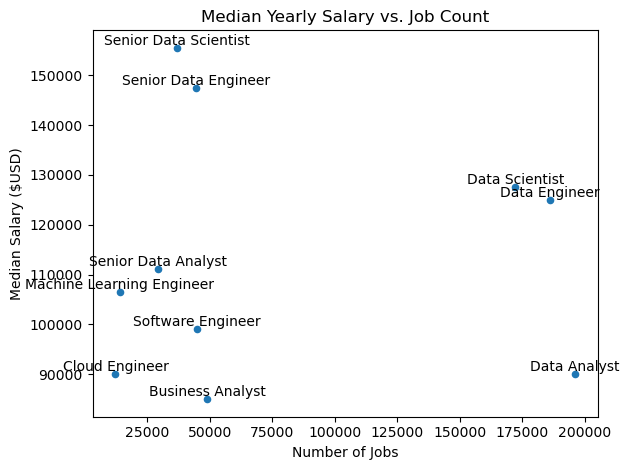

In [3]:
job_stats = df.groupby('job_title_short').agg(
    median_salary = ('salary_year_avg', 'median'),
    job_count = ('job_title_short', 'count')
).dropna()

job_stats.plot(kind='scatter', x='job_count', y='median_salary')

for txt in job_stats.index:
    plt.text(job_stats['job_count'].loc[txt], job_stats['median_salary'].loc[txt], txt, ha='center', va='bottom')

plt.title('Median Yearly Salary vs. Job Count')
plt.xlabel('Number of Jobs')
plt.ylabel('Median Salary ($USD)')
plt.tight_layout()
plt.show()

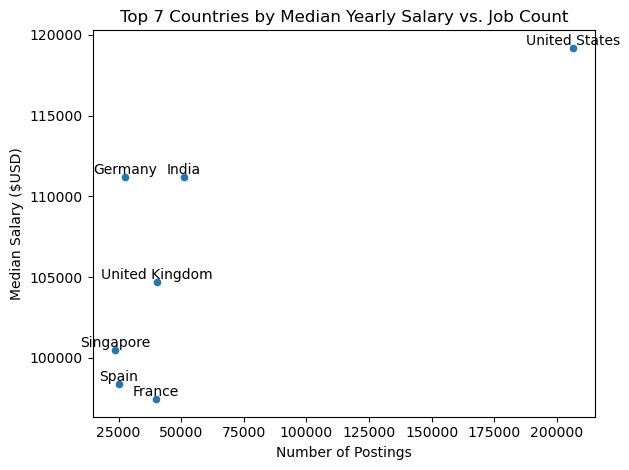

In [4]:
country_stats = df.groupby('job_country').agg(
    postings_count = ('job_title_short', 'count'),
    median_salary = ('salary_year_avg', 'median')
).dropna()

country_stats = country_stats.sort_values(by='postings_count', ascending=False).head(7)

country_stats.plot(kind='scatter', x='postings_count', y='median_salary')

for txt in country_stats.index:
    plt.text(country_stats['postings_count'].loc[txt], country_stats['median_salary'].loc[txt], txt, ha='center', va='bottom')

plt.title('Top 7 Countries by Median Yearly Salary vs. Job Count')
plt.xlabel('Number of Postings')
plt.ylabel('Median Salary ($USD)')
plt.tight_layout()
plt.show()

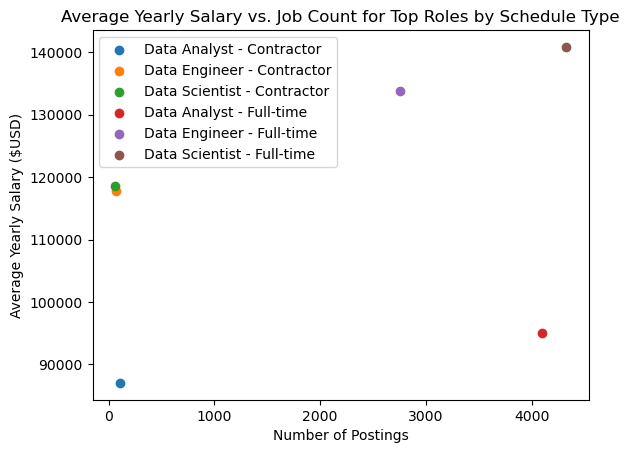

In [63]:
target_job_titles = ['Data Analyst', 'Data Scientist', 'Data Engineer']
us_jobs_df = df[
    (df['job_title_short'].isin(target_job_titles)) &
    (df['job_country'] == 'United States') &
    (df['job_schedule_type'].isin(['Full-time', 'Contractor']))
].dropna(subset='salary_year_avg').copy()

job_stats = us_jobs_df.groupby(['job_schedule_type', 'job_title_short']).agg(
    job_count = ('job_title_short', 'count'),
    average_salary = ('salary_year_avg', 'mean')
).dropna()

job_stats.reset_index(inplace=True)

job_stats['job_title_type'] = job_stats['job_title_short'] + ' - ' + job_stats['job_schedule_type']

for job in job_stats['job_title_type']:
    subset = job_stats[job_stats['job_title_type'] == job]
    plt.scatter(x=subset['job_count'], y=subset['average_salary'], label=job)

plt.title('Average Yearly Salary vs. Job Count for Top Roles by Schedule Type')
plt.ylabel('Average Yearly Salary ($USD)')
plt.xlabel('Number of Postings')
plt.legend()
plt.show()

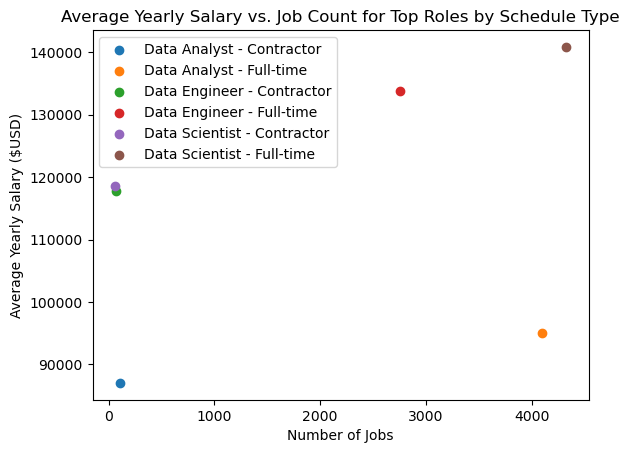

In [76]:
target_job_titles = ['Data Analyst', 'Data Scientist', 'Data Engineer']
us_jobs_df = df[
    (df['job_title_short'].isin(target_job_titles)) &
    (df['job_country'] == 'United States') &
    (df['job_schedule_type'].isin(['Full-time', 'Contractor']))
].dropna(subset='salary_year_avg').copy()

us_jobs_df['job_title_type'] = us_jobs_df.apply(lambda x: x['job_title_short'] + ' - ' + x['job_schedule_type'], axis=1)

job_stats = us_jobs_df.groupby('job_title_type').agg(
    job_count = ('job_title_type', 'count'),
    average_salary = ('salary_year_avg', 'mean')
)

for job in job_stats.index:
    subset = (job_stats[job_stats.index == job])
    plt.scatter(x=subset['job_count'], y=subset['average_salary'], label=job)

plt.xlabel('Number of Jobs')
plt.ylabel('Average Yearly Salary ($USD)')
plt.title('Average Yearly Salary vs. Job Count for Top Roles by Schedule Type')
plt.legend()
plt.show()